#


In [28]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from noisers.classes import URLFNoise
from filters import ENNFilter
# 1. Generar un conjunto de datos de ejemplo
X, y = make_classification(
    n_samples=1000,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    random_state=0
)
# 2. Separar datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
# 3. Añadir ruido a las etiquetas del conjunto de entrenamiento
noise_k=0.15
noiser = URLFNoise(noise_level=noise_k, random_state=42)
X_train_noisy, y_train_noisy = noiser.fit_resample(X_train, y_train)
# 4. Aplicar un filtro de ruido
filter_ = ENNFilter()
X_clean, y_clean = filter_.fit_resample(X_train, y_train_noisy)

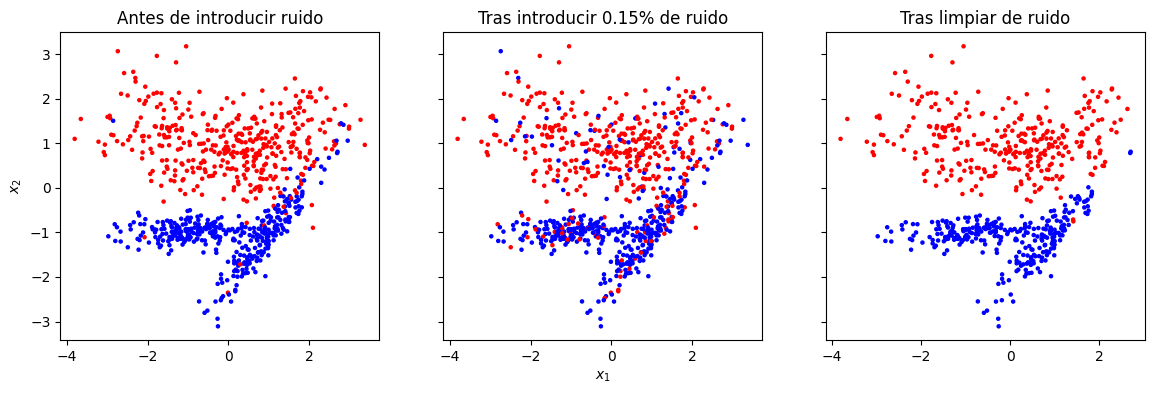

In [47]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14,4))

plt.subplot(1,3,1)
plt.title("Antes de introducir ruido")
plt.ylabel(r"$x_2$")
plt.scatter(X_train[:,0],X_train[:,1], c=y_train, s=5, cmap="bwr")

plt.subplot(1,3,2)
plt.title(f"Tras introducir {noise_k}% de ruido")
plt.tick_params(axis='y', labelleft=False)
plt.xlabel(r"$x_1$")
plt.scatter(X_train_noisy[:,0],X_train_noisy[:,1], c=y_train_noisy, s=5, cmap="bwr")

plt.subplot(1,3,3)
plt.title(f"Tras limpiar de ruido")
plt.tick_params(axis='y', labelleft=False)
plt.scatter(X_clean[:,0],X_clean[:,1], c=y_clean, s=5, cmap="bwr")

plt.show()

# Introduction 
Example notebook about on how to use and take advantage of noise scoring and SHAP values.

In [4]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

from filters import * 
from noisers.classes import URLFNoise

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.base import clone

# Helper funcs

In [3]:
from pathlib import Path

def load_clean_dataset(dataset_name, data_root="./dataset/data_base"):
    """
    Load a clean dataset from the local folder structure.

    Expected file:
        ./dataset/data_base/<dataset_name>/<dataset_name>-<dataset_name>-cc.dat
    """
    path = Path(data_root) / dataset_name / f"{dataset_name}-{dataset_name}-cc.dat"
    if not path.exists():
        raise FileNotFoundError(f"Dataset file not found: {path}")

    lines = path.read_text(encoding="latin-1").splitlines()
    data_idx = next(i for i, line in enumerate(lines) if line.strip().lower() == "@data")

    rows = [line.strip() for line in lines[data_idx + 1:] if line.strip() and not line.strip().startswith("%")]

    X = []
    y = []
    for row in rows:
        parts = [p.strip() for p in row.split(",")]
        X.append([float(v) for v in parts[:-1]])
        y.append(parts[-1])

    return np.asarray(X, dtype=float), np.asarray(y)

# Sim

In [110]:
import numpy as np

from sklearn.base import clone
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, balanced_accuracy_score


# Load clean dataset
X, y = load_clean_dataset("segment")

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=0.8,
    random_state=33,
    shuffle=True,
    stratify=y
)

# Inject NCAR noise into the training set
X_train_noisy, y_train_noisy = URLFNoise(
    noise_level=0.3,
    random_state=33
).fit_resample(X_train, y_train)

noisy_mask = (y_train_noisy != y_train)


# Base classifier with scaling
base_lr = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=5000)
)


# Noise-score filtering
cf = ClassificationFilter(
    estimator=base_lr,
    cv=10,
    action="detect",
    random_state=33,
)

# Optional: fit on clean dataset, only for comparison/analysis
cf_clean = clone(cf).fit(X_train, y_train)

# Fit filter on noisy dataset
cf.fit(X_train_noisy, y_train_noisy)

ns = np.asarray(cf.noise_score_, dtype=float)

# Threshold-based hard filtering
threshold = float(np.mean(ns))
keep_mask = ns <= threshold

X_train_filtered = X_train_noisy[keep_mask]
y_train_filtered = y_train_noisy[keep_mask]


# -------------------------------------------------------
# Convert noise_score into sample_weight
# -------------------------------------------------------

# Higher noise_score -> lower training weight
sample_weight = 1.0 - ns

# Avoid weights exactly equal to 0
sample_weight = np.clip(sample_weight, 0.05, 1.0)

# Important: weights for filtered dataset only
sample_weight_filtered = sample_weight[keep_mask]


# -------------------------------------------------------
# Final models
# -------------------------------------------------------

# 1. Baseline: train on noisy data
model_noisy = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=5000)
)

# 2. Hard filtering: remove suspicious instances
model_filtered = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=5000)
)

# 3. Soft weighting: keep all instances, but downweight suspicious ones
model_weighted = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=5000)
)

# 4. Hybrid: first filter, then weight the remaining instances
model_filtered_weighted = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=5000)
)


# -------------------------------------------------------
# Fit and predict
# -------------------------------------------------------

model_noisy.fit(X_train_noisy, y_train_noisy)
pred_noisy = model_noisy.predict(X_test)


model_filtered.fit(X_train_filtered, y_train_filtered)
pred_filtered = model_filtered.predict(X_test)


model_weighted.fit(
    X_train_noisy,
    y_train_noisy,
    logisticregression__sample_weight=sample_weight
)
pred_weighted = model_weighted.predict(X_test)


model_filtered_weighted.fit(
    X_train_filtered,
    y_train_filtered,
    logisticregression__sample_weight=sample_weight_filtered
)
pred_filtered_weighted = model_filtered_weighted.predict(X_test)


# -------------------------------------------------------
# Results
# -------------------------------------------------------

print(f"Injected noise rate: {noisy_mask.mean():.3f}")
print(f"Noise_score threshold (mean): {threshold:.6f}")
print(f"Filtered samples: {keep_mask.sum()} / {len(keep_mask)}")
print()

print("Without filtering:")
print("  accuracy:", accuracy_score(y_test, pred_noisy))
print("  balanced_accuracy:", balanced_accuracy_score(y_test, pred_noisy))
print()

print("With hard filtering:")
print("  accuracy:", accuracy_score(y_test, pred_filtered))
print("  balanced_accuracy:", balanced_accuracy_score(y_test, pred_filtered))
print()

print("With soft weighting:")
print("  accuracy:", accuracy_score(y_test, pred_weighted))
print("  balanced_accuracy:", balanced_accuracy_score(y_test, pred_weighted))
print()

print("With filtering + weighting:")
print("  accuracy:", accuracy_score(y_test, pred_filtered_weighted))
print("  balanced_accuracy:", balanced_accuracy_score(y_test, pred_filtered_weighted))

Injected noise rate: 0.254
Noise_score threshold (mean): 0.327932
Filtered samples: 1155 / 1848

Without filtering:
  accuracy: 0.8939393939393939
  balanced_accuracy: 0.8939393939393939

With hard filtering:
  accuracy: 0.9047619047619048
  balanced_accuracy: 0.9047619047619048

With soft weighting:
  accuracy: 0.9069264069264069
  balanced_accuracy: 0.9069264069264069

With filtering + weighting:
  accuracy: 0.9025974025974026
  balanced_accuracy: 0.9025974025974026


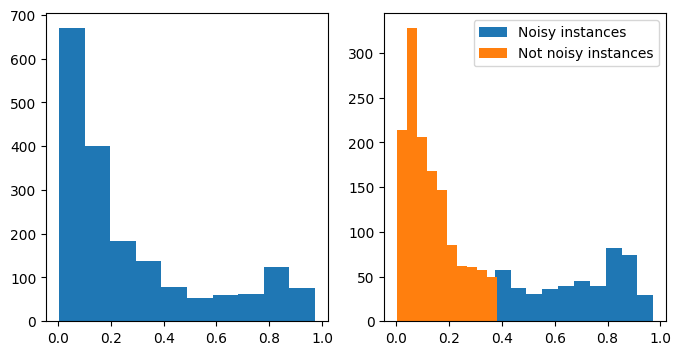

In [ ]:
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.hist(cf.noise_score_)

plt.subplot(1,2,2)
plt.hist(cf.noise_score_[cf.noisy_mask_], label="Noisy instances")
plt.hist(cf.noise_score_[~cf.noisy_mask_], label="Not noisy instances")
plt.legend()

plt.show()

In [102]:
cf.noise_score_[~cf.noisy_mask_].mean(), cf.noise_score_.mean(), cf.noise_score_[cf.noisy_mask_].mean()

(np.float64(0.13097863672363097),
 np.float64(0.2731880821836636),
 np.float64(0.6901340733409507))

In [93]:
np.arange(len(cf.noise_score_))[cf.noise_score_ == cf.noise_score_.max()]

array([953])

In [103]:
report = explain_classification_filter_noisy_instances(
    cf,
    sample_indices=[953],
    noisy_only=False,
    return_figures=True,
    max_evals=500
)

Background dataset has 1663 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=1663 when initializing the masker.


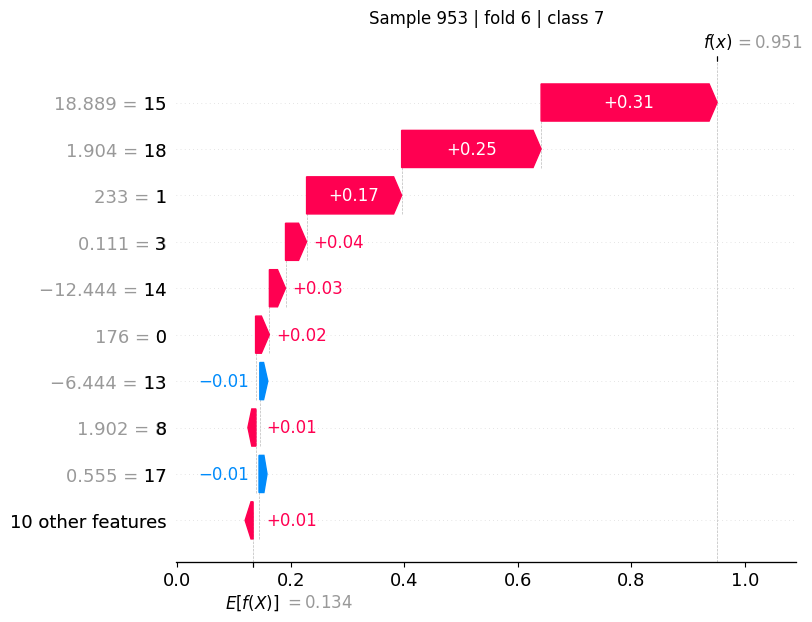

In [106]:
report[0].figure

In [6]:
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score
from sklearn.mixture import GaussianMixture

# -------------------------------------------------------
# Helpers
# -------------------------------------------------------

def safe_row_index(X, mask):
    """
    Permite indexar tanto si X es numpy array como si es pandas DataFrame.
    """
    if hasattr(X, "iloc"):
        return X.iloc[mask]
    return X[mask]


def weights_from_noise_score(noise_score, mode="linear", min_weight=0.05, alpha=3.0):
    """
    Convierte noise_score en sample_weight.

    noise_score alto  -> peso bajo
    noise_score bajo  -> peso alto
    """
    ns = np.asarray(noise_score, dtype=float)
    ns = np.clip(ns, 0.0, 1.0)

    if mode == "linear":
        w = 1.0 - ns

    elif mode == "quadratic":
        w = (1.0 - ns) ** 2

    elif mode == "exp":
        w = np.exp(-alpha * ns)

    else:
        raise ValueError(f"Unknown weight mode: {mode}")

    return np.clip(w, min_weight, 1.0)


def evaluate_predictions(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro"),
    }


def fit_predict_lr(X_train, y_train, X_test, sample_weight=None):
    """
    Entrena LogisticRegression con StandardScaler.
    Si se pasa sample_weight, se aplica solo a LogisticRegression.
    """
    model = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=5000)
    )

    if sample_weight is None:
        model.fit(X_train, y_train)
    else:
        model.fit(
            X_train,
            y_train,
            logisticregression__sample_weight=sample_weight
        )

    return model.predict(X_test)

class NoiseScoreThresholding:
    """
    Umbralado adaptativo para noise_score.

    Permite convertir un vector continuo de noise_score en una máscara binaria
    de instancias detectadas como ruidosas.

    Métodos soportados:
    - mean
    - median
    - percentile
    - otsu
    - gmm

    En el caso de GMM se ajusta una mezcla gaussiana de dos componentes sobre
    los noise_score. La componente con menor media se interpreta como limpia,
    y la de mayor media como ruidosa.
    """

    def __init__(
        self,
        method="mean",
        posterior_threshold=0.5,
        percentile=75,
        grid_size=1000,
        min_separability=None,
        fallback="mean",
        random_state=None,
    ):
        self.method = method
        self.posterior_threshold = posterior_threshold
        self.percentile = percentile
        self.grid_size = grid_size
        self.min_separability = min_separability
        self.fallback = fallback
        self.random_state = random_state

    def fit(self, noise_score):
        ns = np.asarray(noise_score, dtype=float)

        if ns.ndim != 1:
            raise ValueError("noise_score must be a 1D array.")

        if len(ns) == 0:
            raise ValueError("noise_score cannot be empty.")

        if not np.all(np.isfinite(ns)):
            raise ValueError("noise_score contains NaN or infinite values.")

        if np.min(ns) < -1e-8 or np.max(ns) > 1.0 + 1e-8:
            raise ValueError(
                "noise_score values must be in [0, 1]. "
                "If this is caused by numerical precision, clip them before calling fit()."
            )

        ns = np.clip(ns, 0.0, 1.0)

        self.noise_score_ = ns
        self.method_requested_ = self.method
        self.fallback_used_ = False
        self.posterior_noise_ = None
        self.component_means_ = None
        self.component_weights_ = None
        self.overlap_ = None
        self.separability_score_ = None
        self.bic_ = None
        self.aic_ = None
        self.converged_ = None
        self.diagnostics_ = {}

        method = self.method.lower()

        if method in {"mean", "median", "percentile", "otsu"}:
            self._fit_simple_threshold(method, ns)

        elif method == "gmm":
            self._fit_gmm(ns)

        else:
            raise ValueError(f"Unknown thresholding method: {self.method}")

        self.noisy_mask_ = self._compute_noisy_mask(ns)

        return self

    def predict(self, noise_score=None):
        if noise_score is None:
            return self.noisy_mask_

        ns = np.asarray(noise_score, dtype=float)
        ns = np.clip(ns, 0.0, 1.0)

        if self.posterior_noise_ is not None and len(ns) == len(self.noise_score_):
            return self.posterior_noise_ >= self.posterior_threshold

        return ns > self.threshold_

    def fit_predict(self, noise_score):
        self.fit(noise_score)
        return self.noisy_mask_

    def _fit_simple_threshold(self, method, ns):
        if method == "mean":
            threshold = float(np.mean(ns))

        elif method == "median":
            threshold = float(np.median(ns))

        elif method == "percentile":
            threshold = float(np.percentile(ns, self.percentile))

        elif method == "otsu":
            threshold = self._otsu_threshold(ns)

        else:
            raise ValueError(f"Unknown simple threshold method: {method}")

        self.threshold_ = threshold
        self.method_ = method
        self.diagnostics_ = {
            "method": method,
            "threshold": threshold,
            "fallback_used": self.fallback_used_,
        }

    def _fit_gmm(self, ns):
        # Casos degenerados: todos los scores prácticamente iguales
        if np.allclose(ns, ns[0]):
            self._use_fallback(ns, reason="All noise_score values are almost equal.")
            return

        if len(ns) < 4:
            self._use_fallback(ns, reason="Too few samples for GMM thresholding.")
            return

        X = ns.reshape(-1, 1)

        try:
            gmm = GaussianMixture(
                n_components=2,
                covariance_type="full",
                random_state=self.random_state,
            )
            gmm.fit(X)

            probs = gmm.predict_proba(X)
            means = gmm.means_.ravel()
            weights = gmm.weights_.ravel()

            clean_component = int(np.argmin(means))
            noise_component = int(np.argmax(means))

            posterior_noise = probs[:, noise_component]

            threshold = self._threshold_from_gmm(
                gmm=gmm,
                clean_component=clean_component,
                noise_component=noise_component,
            )

            overlap, separability = self._gmm_overlap_and_separability(
                gmm=gmm,
                clean_component=clean_component,
                noise_component=noise_component,
            )

            self.threshold_ = threshold
            self.method_ = "gmm"
            self.posterior_noise_ = posterior_noise
            self.component_means_ = means
            self.component_weights_ = weights
            self.overlap_ = overlap
            self.separability_score_ = separability
            self.bic_ = float(gmm.bic(X))
            self.aic_ = float(gmm.aic(X))
            self.converged_ = bool(gmm.converged_)

            self.diagnostics_ = {
                "method": "gmm",
                "threshold": self.threshold_,
                "posterior_threshold": self.posterior_threshold,
                "component_means": self.component_means_.tolist(),
                "component_weights": self.component_weights_.tolist(),
                "clean_component": clean_component,
                "noise_component": noise_component,
                "overlap": self.overlap_,
                "separability_score": self.separability_score_,
                "bic": self.bic_,
                "aic": self.aic_,
                "converged": self.converged_,
                "fallback_used": self.fallback_used_,
            }

            if (
                self.min_separability is not None
                and self.separability_score_ is not None
                and self.separability_score_ < self.min_separability
            ):
                self._use_fallback(
                    ns,
                    reason=(
                        f"GMM separability_score={self.separability_score_:.4f} "
                        f"is lower than min_separability={self.min_separability}."
                    ),
                )

        except Exception as exc:
            self._use_fallback(ns, reason=f"GMM failed: {repr(exc)}")

    def _threshold_from_gmm(self, gmm, clean_component, noise_component):
        grid = np.linspace(0.0, 1.0, self.grid_size).reshape(-1, 1)
        probs_grid = gmm.predict_proba(grid)
        posterior_noise_grid = probs_grid[:, noise_component]

        means = gmm.means_.ravel()
        clean_mean = means[clean_component]
        noise_mean = means[noise_component]

        grid_flat = grid.ravel()

        # Buscamos preferentemente el cruce entre las dos medias.
        between_means = (grid_flat >= clean_mean) & (grid_flat <= noise_mean)

        if np.any(between_means):
            candidate_grid = grid_flat[between_means]
            candidate_post = posterior_noise_grid[between_means]

            idx = int(np.argmin(np.abs(candidate_post - self.posterior_threshold)))
            return float(candidate_grid[idx])

        # Fallback: primer punto donde posterior_noise supera el umbral.
        valid = posterior_noise_grid >= self.posterior_threshold

        if np.any(valid):
            return float(grid_flat[valid][0])

        # Último fallback: media de los scores originales.
        return float(np.mean(self.noise_score_))

    def _gmm_overlap_and_separability(self, gmm, clean_component, noise_component):
        grid = np.linspace(0.0, 1.0, self.grid_size)

        means = gmm.means_.ravel()
        weights = gmm.weights_.ravel()
        variances = gmm.covariances_.reshape(2, -1).ravel()

        def weighted_gaussian_pdf(x, component):
            mu = means[component]
            var = max(float(variances[component]), 1e-12)
            sigma = np.sqrt(var)

            pdf = (
                1.0 / (sigma * np.sqrt(2.0 * np.pi))
                * np.exp(-0.5 * ((x - mu) / sigma) ** 2)
            )

            return weights[component] * pdf

        clean_density = weighted_gaussian_pdf(grid, clean_component)
        noise_density = weighted_gaussian_pdf(grid, noise_component)

        overlap = float(np.trapz(np.minimum(clean_density, noise_density), grid))
        overlap = float(np.clip(overlap, 0.0, 1.0))

        separability = 1.0 - overlap

        return overlap, separability

    def _otsu_threshold(self, ns):
        hist, bin_edges = np.histogram(ns, bins=256, range=(0.0, 1.0))
        hist = hist.astype(float)

        total = hist.sum()

        if total == 0:
            return float(np.mean(ns))

        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2.0

        weight_0 = np.cumsum(hist)
        weight_1 = total - weight_0

        sum_total = np.sum(hist * bin_centers)
        sum_0 = np.cumsum(hist * bin_centers)
        sum_1 = sum_total - sum_0

        valid = (weight_0 > 0) & (weight_1 > 0)

        if not np.any(valid):
            return float(np.mean(ns))

        mean_0 = np.zeros_like(bin_centers)
        mean_1 = np.zeros_like(bin_centers)

        mean_0[valid] = sum_0[valid] / weight_0[valid]
        mean_1[valid] = sum_1[valid] / weight_1[valid]

        between_class_variance = np.zeros_like(bin_centers)
        between_class_variance[valid] = (
            weight_0[valid]
            * weight_1[valid]
            * (mean_0[valid] - mean_1[valid]) ** 2
        )

        idx = int(np.argmax(between_class_variance))

        return float(bin_centers[idx])

    def _compute_noisy_mask(self, ns):
        if self.posterior_noise_ is not None and len(self.posterior_noise_) == len(ns):
            return self.posterior_noise_ >= self.posterior_threshold

        return ns > self.threshold_

    def _use_fallback(self, ns, reason):
        previous_diagnostics = getattr(self, "diagnostics_", {})

        self.fallback_used_ = True

        fallback = self.fallback.lower()

        if fallback not in {"mean", "median", "percentile", "otsu"}:
            raise ValueError(
                f"Invalid fallback={self.fallback}. "
                "Use one of: mean, median, percentile, otsu."
            )

        self._fit_simple_threshold(fallback, ns)

        self.method_ = fallback
        self.method_requested_ = self.method

        self.posterior_noise_ = None
        self.component_means_ = None
        self.component_weights_ = None
        self.overlap_ = None
        self.separability_score_ = None
        self.bic_ = None
        self.aic_ = None
        self.converged_ = None
        self.fallback_used_ = True

        self.diagnostics_ = {
            **previous_diagnostics,
            "method_requested": self.method_requested_,
            "method_used": fallback,
            "threshold": self.threshold_,
            "fallback_used": True,
            "fallback_reason": reason,
        }

# -------------------------------------------------------
# Experimento sobre un dataset
# -------------------------------------------------------

def run_one_dataset(
    dataset_name,
    noise_level=0.3,
    random_state=33,
    train_size=0.8,
    cv=10,
    threshold_strategy="mean",
    posterior_threshold=0.5,
    percentile=75,
    min_separability=None,
    fallback_threshold_strategy="mean",
    weight_mode="linear",
    min_weight=0.05,
):
    # Load clean dataset
    X, y = load_clean_dataset(dataset_name)

    y = np.asarray(y)

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        train_size=train_size,
        random_state=random_state,
        shuffle=True,
        stratify=y
    )

    # Inject NCAR noise into the training set
    X_train_noisy, y_train_noisy = URLFNoise(
        noise_level=noise_level,
        random_state=random_state
    ).fit_resample(X_train, y_train)

    y_train_noisy = np.asarray(y_train_noisy)

    # True injected noisy mask
    noisy_mask = (y_train_noisy != y_train)

    # Effective CV, to avoid problems with small classes
    _, class_counts = np.unique(y_train_noisy, return_counts=True)
    cv_eff = min(cv, int(class_counts.min()))

    if cv_eff < 2:
        raise ValueError(
            f"Dataset {dataset_name}: not enough samples per class for CV. "
            f"Minimum class count: {class_counts.min()}"
        )

    # Base classifier with scaling
    base_lr = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=5000)
    )

    # Noise-score filtering
    cf = ClassificationFilter(
        estimator=base_lr,
        cv=cv_eff,
        action="detect",
        random_state=random_state,
    )

    # Optional: fit on clean dataset, only if you want to inspect it later
    cf_clean = clone(cf).fit(X_train, y_train)

    # Fit filter on noisy dataset
    cf.fit(X_train_noisy, y_train_noisy)

    ns = np.asarray(cf.noise_score_, dtype=float)

    # Adaptive thresholding
    threshold_model = NoiseScoreThresholding(
        method=threshold_strategy,
        posterior_threshold=posterior_threshold,
        percentile=percentile,
        min_separability=min_separability,
        fallback=fallback_threshold_strategy,
        random_state=random_state,
    )

    detected_noisy_mask = threshold_model.fit_predict(ns)

    keep_mask = ~detected_noisy_mask
    threshold = threshold_model.threshold_

    keep_mask = ns <= threshold

    X_train_filtered = safe_row_index(X_train_noisy, keep_mask)
    y_train_filtered = y_train_noisy[keep_mask]

    # sample_weight for all noisy training samples
    sample_weight = weights_from_noise_score(
        ns,
        mode=weight_mode,
        min_weight=min_weight,
    )

    # sample_weight for filtered samples only
    sample_weight_filtered = sample_weight[keep_mask]

    # -------------------------------------------------------
    # Final models
    # -------------------------------------------------------

    # 1. Baseline: noisy training
    pred_noisy = fit_predict_lr(
        X_train_noisy,
        y_train_noisy,
        X_test,
        sample_weight=None
    )

    # 2. Hard filtering
    pred_filtered = fit_predict_lr(
        X_train_filtered,
        y_train_filtered,
        X_test,
        sample_weight=None
    )

    # 3. Soft weighting without filtering
    pred_weighted = fit_predict_lr(
        X_train_noisy,
        y_train_noisy,
        X_test,
        sample_weight=sample_weight
    )

    # 4. Hard filtering + weighting
    pred_filtered_weighted = fit_predict_lr(
        X_train_filtered,
        y_train_filtered,
        X_test,
        sample_weight=sample_weight_filtered
    )

    # -------------------------------------------------------
    # Metrics
    # -------------------------------------------------------

    rows = []

    common_info = {
        "dataset": dataset_name,
        "n_samples": len(y),
        "n_train": len(y_train),
        "n_test": len(y_test),
        "n_classes": len(np.unique(y)),
        "noise_level": noise_level,
        "injected_noise_rate": float(noisy_mask.mean()),
        "cv": cv_eff,
        "threshold_strategy": threshold_strategy,
        "threshold": threshold,
        "filtered_samples": int(keep_mask.sum()),
        "removed_samples": int((~keep_mask).sum()),
        "removed_fraction": float((~keep_mask).mean()),
        "weight_mode": weight_mode,
        "min_weight": min_weight,
    }

    preds = {
        "noisy": pred_noisy,
        "hard_filtering": pred_filtered,
        "soft_weighting": pred_weighted,
        "filtering_plus_weighting": pred_filtered_weighted,
    }

    for method, pred in preds.items():
        metrics = evaluate_predictions(y_test, pred)
        rows.append({
            **common_info,
            "method": method,
            **metrics,
        })

    result = pd.DataFrame(rows)

    return result

In [122]:
datasets = [
    "iris",
    "wine",
    "glass",
    "segment",
    "vehicle",
    "vowel",
    "ecoli",
    "yeast",
    "zoo",
    "lymphography",
    "hayes-roth",
    "heart",
    "hepatitis",
    "ionosphere",
    "sonar",
    "pima",
    "banana",
    "appendicitis",
    "australian",
    "bupa",
    "cleveland",
    "tae",
    "wisconsin",
    "spambase",
    "phoneme",
    "magic",
]

In [129]:
results_df[["method", "balanced_accuracy"]].groupby("method").mean().sort_values(by="balanced_accuracy")

,balanced_accuracy
method,
filtering_plus_weighting,0.679518
hard_filtering,0.680840
noisy,0.705053
soft_weighting,0.719492
